# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:


---

## Zestaw zadań 9: Badanie intensywności procesów punktowych oraz relacji między punktami (część 3)

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import shapely

In [2]:
# Miejsce do importu pakietów wchodzących w skład standardowej biblioteki Pythona oraz ustawienie opcji wykorzystywanych pakietów

### Wczytanie danych
Poniższy kod wczytuje do zmiennych `poland`, `points_1`, `points_2`, `points_3`, `points_4`, `points_5`, `points_6`, `test_points_1` oraz `test_points_2` dane z pliku data.gpkg.
<img src="Wczytane rozkłady.png">

In [3]:
poland = gpd.read_file("data.gpkg", layer='poland')
poland

,Nazwa,geometry
0,Polska,"POLYGON ((495817.822 183473.276, 495778.757 18..."


In [4]:
points_1 = gpd.read_file("data.gpkg", layer='points_R')
points_1.head()

,geometry
0,POINT (746726.814 164535.535)
1,POINT (561669.012 179254.158)
2,POINT (575522.076 176268.791)
3,POINT (727348.477 178177.739)
4,POINT (749495.901 176165.143)


In [5]:
points_2 = gpd.read_file("data.gpkg", layer='points_P')
points_2.head()

,geometry
0,POINT (458336.668 682611.54)
1,POINT (264451.331 421768.917)
2,POINT (716458.063 211411.884)
3,POINT (333437.357 309193.537)
4,POINT (438396.636 631242.241)


In [6]:
points_3 = gpd.read_file("data.gpkg", layer='points_T')
points_3.head()

,geometry
0,POINT (638062.941 689433.083)
1,POINT (625542.51 692000.369)
2,POINT (638701.807 697065.653)
3,POINT (649499.586 696696.79)
4,POINT (650911.338 705624.982)


In [7]:
points_4 = gpd.read_file("data.gpkg", layer='points_irregular_1')
points_4.head()

,geometry
0,POINT (373266.77 309904.674)
1,POINT (327565.113 557294.55)
2,POINT (259082.601 627044.747)
3,POINT (395412.618 512308.953)
4,POINT (618422 410635.469)


In [8]:
points_5 = gpd.read_file("data.gpkg", layer='points_irregular_2')
points_5.head()

,geometry
0,POINT (390227.401 636925.915)
1,POINT (512575.743 593526.95)
2,POINT (533168.573 677492.219)
3,POINT (340246.72 627187.936)
4,POINT (531741.249 592646.587)


In [9]:
points_6 = gpd.read_file("data.gpkg", layer='points_irregular_3')
points_6.head()

,geometry
0,POINT (280067.917 587721.418)
1,POINT (436074.785 616102.437)
2,POINT (324352.281 509680.956)
3,POINT (625211.069 504415.876)
4,POINT (634202.324 241248.608)


In [10]:
test_points_1 = gpd.read_file("data.gpkg", layer='test_points_1')
test_points_1.head()

,geometry
0,POINT (364732.092 723385.55)
1,POINT (309246.986 665351.724)
2,POINT (352441.728 328023.909)
3,POINT (330186.768 278858.464)
4,POINT (338057.193 310040.858)


In [11]:
test_points_2 = gpd.read_file("data.gpkg", layer='test_points_2')
test_points_2.head()

,geometry
0,POINT (772135.965 296659.579)
1,POINT (538469.034 563812.648)
2,POINT (663869.176 526441.807)
3,POINT (364246.384 566134.494)
4,POINT (570612.962 452339.895)


### Miejsce na wklejenie funkcji z poprzednich zestawów zadań

Rozwiązanie zadań w tym notatniku będzie wymagało skorzystania funkcji `rectangular_grid_over_polygon()` oraz `point_statistic_on_subregions()` przygotowanych w zestawie zadań 7. Wklej do poniższej komórki przygotowane przez siebie funkcje.

In [12]:
def rectangular_grid_over_polygon(polygon, crs, bins):
    """
    Parameters
    -------
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego mają zostać wygenerowane punkty.
    crs: str, int, pyproj.crs.crs.CRS
        Układ odniesienia przypisany do wynikowego GeoDataFrame.
        Powinien odpowiadać układowi współrzędnych wejściowego poligonu.
    bins: list
        Lista określająca liczbę punktów w siatce w poziomie i w pionie.
        Przykład: [20, 10]

    Returns
    -------
    grid : geopandas.GeoDataFrame
        Tablica zawierająca prostokątne komórki siatki, przycięte do obszaru 
        wejściowego poligonu i zapisane w układzie odniesienia `crs`.
    """
    minx, miny, maxx, maxy = polygon.bounds

    x_dolne = np.linspace(minx, maxx, bins[0], endpoint=False)
    y_dolne = np.linspace(miny, maxy, bins[1], endpoint=False)

    dx = (maxx - minx)/bins[0]
    dy = (maxy - miny)/bins[1]

    x_gorne = x_dolne + dx
    y_gorne = y_dolne + dy

    x0, y0 = np.meshgrid(x_dolne, y_dolne)
    x1, y1 = np.meshgrid(x_gorne, y_gorne)

    siatka = shapely.box(x0, y0, x1, y1)

    siatka_pol = shapely.intersection(siatka, polygon)

    mask = shapely.is_empty(siatka_pol)

    siatka_final = siatka_pol[~mask]

    df = gpd.GeoDataFrame(geometry=siatka_final, crs=crs)

    return df
    

def point_statistic_on_subregions(points, subregions, statistic="counts"):
    """
    Parameters
    -------
    points : geopandas.GeoDataFrame
        Zbiór punktów wejściowych, na podstawie których estymowana jest intensywność.
    subregions : geopandas.GeoDataFrame
        Zbiór podobszarów poligonalnych, do których przypisywane są punkty.
    statistic : str
        Rodzaj statystyki obliczanej dla podobszarów:
        - "counts": liczba punktów przypadających na każdy podobszar,
        - "intensity": intensywność procesu (liczba punktów na jednostkę powierzchni podobszaru).

    Returns
    -------
    statistic_on_subregions : geopandas.GeoDataFrame
        Tablica zawierająca:
        - kolumnę "counts" lub "intensity" z wartościami oszacowanej statystyki,
        - geometrię  reprezentującą siatkę podobszarów.
    """

    polaczenie = gpd.sjoin(points, subregions, how='left', predicate='within')
    
    counts = polaczenie.groupby('index_right').size() 
    
    podobszary = gpd.GeoDataFrame(geometry=subregions.geometry, crs=subregions.crs)

    if statistic == "counts":
        podobszary['counts'] = counts
        podobszary['counts'] = podobszary['counts'].fillna(0)
    elif statistic == "intensity":
        podobszary["intensity"] = counts/podobszary.area
        podobszary["intensity"] = podobszary["intensity"].fillna(0)
    else:
        raise ValueError("Dostępne statystyki to: 'counts' lub 'intensity'.")
    
    return podobszary

### Gotowe funkcje do wykorzystania w zadaniach

In [13]:
def vizualize_test_result(pdf, statistic, rejection_region):
    """
    Parameters
    -------
    pdf: pandas.DataFrame
        Tablica zawierająca informacje niezbędne do wykreślenia funkcji gęstości prawdopodobieństwa wykorzystywanego w teście rozkładu
        teoretycznego - index z wariantami zmiennej losowej i nadaną nazwą zmiennej (np. x) oraz pojedynczą kolumnę z wartościami
        gęstościami prawdopodobieństwa wyliczonymi dla poszczególnych wariantów o nadanej nazwie bazującej na nazwie zmiennej (np. f(x)).
    statistic: float
        Wartość statystyki testowej wyliczonej na podstawie próby losowej.
    rejection_region: list
        Lista zawierająca trzy elementy pozwalające na określenie obszaru krytycznego w następującej kolejności:
         - wartość dolnej granicy przedziału,
         - wartość górnej granicy przedziału,
         - "inner" lub "outer" w zależności od tego, czy ma być zakolorowana wewnętrzna, czy zewnętrzna część przedziału.
    """
    pdf_name= pdf.columns[0]
    
    fig, axes = plt.subplots(1, 1, figsize=(8, 3), facecolor='white')

    axes.plot(pdf.index, pdf[pdf_name], color="grey")

    if rejection_region[2]=="inner":
        axes.fill_between(pdf.index, pdf[pdf_name], 0, where=((pdf.index > rejection_region[0]) & (pdf.index<rejection_region[1])), color='red', alpha=0.5)
    elif rejection_region[2]=="outer":
        axes.fill_between(pdf.index, pdf[pdf_name], 0, where=((pdf.index < rejection_region[0]) | (pdf.index>rejection_region[1])), color='red', alpha=0.5)
    
    axes.vlines(x=statistic, ymin=0, ymax=np.max(pdf[pdf_name]/3), color="blue")
    
    axes.set_xlabel(pdf.index.name)
    axes.set_ylabel(pdf_name)

In [14]:
def uniform_poisson_xy_cdfs(polygon, n_splits=100):
    """
    Buduje brzegowe funkcje dystrybuanty (CDF) F_X i F_Y dla
    jednorodnego procesu Poissona ograniczonego do zadanego poligonu.

    Parameters
    ----------
    polygon: shapely.geometry.polygon.Polygon
        Obszar, wewnątrz którego zakładamy jednorodny proces Poissona.
    n_splits : int
        Liczba punktów siatki wzdłuż osi X i Y używana do aproksymacji CDF.
        Większa wartość zwiększa dokładność, ale też koszt obliczeń.
        
    Returns
    -------
    cdf_x : callable
        Funkcja dystrybuanty brzegowej F_X kompatybilna z scipy.stats.kstest().
    cdf_y : callable
        Funkcja dystrybuanty brzegowej F_Y kompatybilna z scipy.stats.kstest().
    """
    xmin, ymin, xmax, ymax = polygon.bounds
    total_area = polygon.area

    xs_grid = np.linspace(xmin, xmax, n_splits)
    ys_grid = np.linspace(ymin, ymax, n_splits)

    FX_grid = np.zeros(n_splits)
    FY_grid = np.zeros(n_splits)

    # Precompute F_X
    for i, x in enumerate(xs_grid):
        slice_poly = polygon.intersection(shapely.geometry.box(xmin, ymin, x, ymax))
        FX_grid[i] = slice_poly.area / total_area

    # Precompute F_Y
    for i, y in enumerate(ys_grid):
        slice_poly = polygon.intersection(shapely.geometry.box(xmin, ymin, xmax, y))
        FY_grid[i] = slice_poly.area / total_area

    def cdf_x(values):
        values = np.asarray(values)
        return np.interp(values, xs_grid, FX_grid)

    def cdf_y(values):
        values = np.asarray(values)
        return np.interp(values, ys_grid, FY_grid)

    return cdf_x, cdf_y

In [15]:
cdf_x, cdf_y = uniform_poisson_xy_cdfs(poland.geometry[0], n_splits=200)

### Zadanie 1: Wykres Morishity [10 pkt]

#### a) Przygotowanie funkcji

Przygotuj funkcję `morishita_plot_data()`, która będzie generować dane niezbędne do wykonania wykresu Morishity analizowanego rozkładu punktów.

Algorytm postępowania:

1. Przeiteruj w pętli `for` po wszystkich rozdzielczościach siatki. Dla każdej z nich:

   - Użyj funkcji `rectangular_grid_over_polygon()`, aby utworzyć siatkę pokrywającą analizowany obszar.

   - Skorzystaj z funkcji `point_statistic_on_subregions()`, aby obliczyć liczbę punktów w każdej komórce.  

   - Oblicz indeks Morishity dla danej siatki stosując wzór:
  
       $I_\delta = \frac{n \sum_i x_i(x_i - 1)}{N(N - 1)}$

       gdzie:  
       - $x_i$ – liczba punktów w i-tej komórce,  
       - $n$ – liczba komórek siatki,  
       - $N$ – łączna liczba punktów.

   - Korzystając z własności `geopandas.GeoSeries.area` oblicz średnią powierzchnię komórki siatki.

2. Zbierz otrzymane wyniki i utwórz na ich podstawie tablicę `pandas.DataFrame` zawierająca kolumny:
   - 'A' – średnia powierzchnia komórki,
   - 'MI' – wartość indeksu Morishity.

3. Zwróć utworzoną tablicę.

In [16]:
def morishita_plot_data(points, polygon, bins_list):
    """
    Parameters
    ---------
    points : geopandas.GeoDataFrame
        Zbiór punktów analizowangeo procesu punktowego.
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu ograniczającego analizowany obszar.
        Powinien mieć crs identyczny z crs wejściowego rozkładu punktów.
    bins_list : list
        Lista rozdzielczości siatki w formacie [[nx1, ny1], [nx2, ny2], ...].

    Returns
    -------
    morishita_plot: pandas.DataFrame
        Dane do wykresu funkcji morishity, zawierające kolumny:
        - 'A': średnia powierzchnia pojedynczej komórki siatki
        - 'MI': wartość indeksu Morishity
    """

    A = []
    MI = []
    for bins in bins_list:
        siatka = rectangular_grid_over_polygon(polygon, '2180', bins)
        punkty = point_statistic_on_subregions(points, siatka, statistic="counts")

        n=len(siatka)
        N=len(points)

        indeks = n/(N*(N-1))*sum(punkty.counts*(punkty.counts-1))
        MI.append(indeks)
        area = siatka.geometry.area.mean()
        A.append(area)

    return pd.DataFrame({
        'A': A,
        'MI': MI
    })

In [17]:
# Komórka testowa
test_result_1 = morishita_plot_data(test_points_1, poland.geometry[0], [[2,2], [6,6], [10,10], [14,14], [18,18]])
assert type(test_result_1) == pd.DataFrame
assert test_result_1.shape == (5, 2)
assert set(test_result_1.columns) == set(['A', "MI"])
assert np.all(np.isclose(test_result_1.min().values, np.array([1.16606957e+09, 1.29423051e+00])))
assert np.all(np.isclose(test_result_1.mean().values, np.array([1.87633115e+10, 2.43079463e+00])))
assert np.all(np.isclose(test_result_1.max().values, np.array([7.81266611e+10, 2.78142461e+00])))

#### b) Zastosowanie funkcji i wizualizacja wyniku

Wykorzystaj przygotowaną wcześniej funkcję `morishita_plot_data()` do zbadania relacji przestrzennych pomiędzy punktami wszystkich wczytanych do notatnika rozkładów (`points_1`, `points_2`, `points_3`).
Dokonaj obliczeń na siatkach podobszarów 1x1, 3x3, 5x5, ... 40x40.

Następnie, korzystając z funkcji pakietu matplotlib i seaborn oraz funkcji `geopandas.GeoDataFrame.plot()` zwizualizuj wyniki na pojedynczej figurze (siatka wykresów 2x3).

W górnym rzędzie przedstaw analizowane rozkłady punktów. Wizualizacja dla każdego rozkładu powinna zawierać:
    
- granice poligonu, w obrębie którego prowadzona jest analiza,
- rozkład punktowy, który został poddany analizie.

W dolnym wierszu umieść wykresy Morishity analizowanych rozkładów. Dla wszystkich wykresów ustaw identyczny zakres osi X i Y oraz logarytmiczną skalę osi X.

Przygotuj figurę zgodnie z wytycznymi z nagłówka notatnika. Ustaw inne od domyślnych parametry wykresu oraz wizualizowanych obiektów (wielkość figury, kolory, grubość linii, wielkość punktów itp.) tak aby wygenerowane wykresy były przejrzyste i czytelne.

In [18]:
bins = [[i,i] for i in range(1,41,2)]

m1 = morishita_plot_data(points_1, poland.geometry[0], bins)
m2 = morishita_plot_data(points_2, poland.geometry[0], bins)
m3 = morishita_plot_data(points_3, poland.geometry[0], bins)

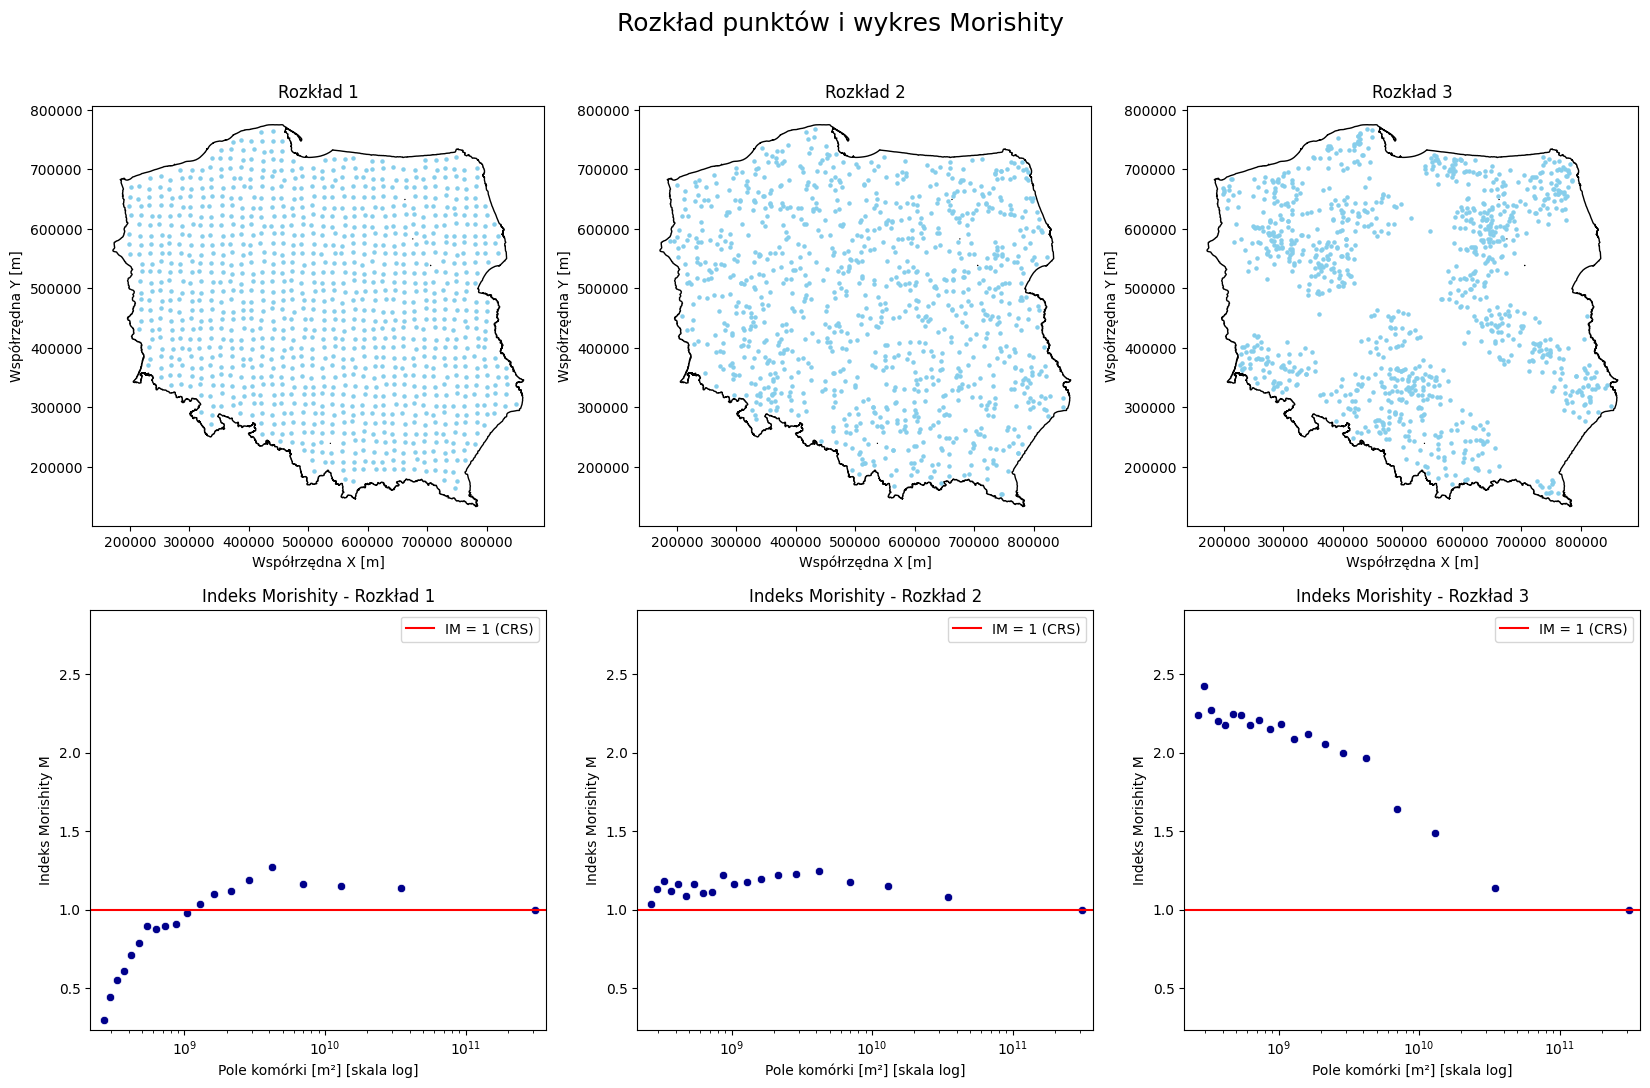

In [19]:
rozklady = ['Rozkład 1', 'Rozkład 2', 'Rozkład 3']
pkt = [points_1, points_2, points_3]

mor = [m1, m2, m3]

x_lim_min = min(m1.A.min(), m2.A.min(), m3.A.min())*0.8
x_lim_max = max(m1.A.max(), m2.A.max(), m3.A.max())*1.2

y_lim_min = min(m1.MI.min(), m2.MI.min(), m3.MI.min())*0.8
y_lim_max = max(m1.MI.max(), m2.MI.max(), m3.MI.max())*1.2

fig, axes = plt.subplots(2,3, figsize=(20,12))

for p, name, ax in zip(pkt, rozklady, axes[0]):

    poland.plot(
        ax=ax,
        color='none',
        edgecolor='black',
        zorder=1
    )

    p.plot(
        ax=ax,
        markersize=5,
        color='skyblue',
        zorder=2
    )

    ax.set_title(name)
    ax.set_xlabel('Współrzędna X [m]')
    ax.set_ylabel('Współrzędna Y [m]')

for m, name, ax in zip(mor, rozklady, axes[1]):
    sns.scatterplot(data=m, x='A', y='MI', color='darkblue', ax=ax)
    ax.set_xscale('log')
    ax.set_xlim(x_lim_min, x_lim_max)
    ax.set_ylim(y_lim_min, y_lim_max)
    ax.set_xlabel('Pole komórki [m²] [skala log]')
    ax.set_ylabel('Indeks Morishity M')
    ax.set_title(f'Indeks Morishity - {name}')
    ax.axhline(y=1, color='red', label='IM = 1 (CRS)')
    ax.legend()

plt.suptitle('Rozkład punktów i wykres Morishity', fontsize=18, y=0.96)
plt.show()

### Zadanie 2: Test chi-kwadrat [8 pkt]

### a) Przygotowanie funkcji

Przygotuj funkcję `chi2_uniform_poisson()` tak, aby przeprowadzała test chi-kwadrat jednorodności procesu punktowego, a następnie wizualizowała wynik testu z wykorzystaniem funkcji `vizualize_test_result()`.

Algorytm postępowania:

1. Użyj funkcji `rectangular_grid_over_polygon()`, aby utworzyć siatkę prostokątnych regionów zgodnie z wartościami przyjętymi podczas wywołania funkcji.

2. Korzystając z funkcji `point_statistic_on_subregions()`, uzyskaj liczność obserwacji w poszczególnych podobszarach.

3. Dla jednorodnego procesu Poissona oczekiwana liczba punktów w komórce jest proporcjonalna do jej pola:  
   
   $E_i = N \cdot \frac{A_i}{A}$

   gdzie:

   - $N$ - liczba punktów analizowanego procesu,

   - $A_i$ — pole i-tej komórki,

   - $A$ - sumaryczne pole wszystkich komórek.  

   Wyznacz wektor wartości oczekiwanych ilości punktów w poszczególnych komórkach.

5. Zastosuj funkcję `scipy.stats.chisquare()` do porównania rzeczywistej i oczekiwanej liczby punktów w poszczególnych komórkach. Ustaw odpowiednią liczbę stopni swobody.

6. Podejmij decyzję weryfikującą i zapisz wynik jako zmienną `H` (1 — odrzucenie H0, 0 — brak podstaw do odrzucenia H0).

7. Przygotuj wizualizację wyniku testu:
   - Korzystając z `scipy.stats.chi2.ppf()` oblicz wartość krytyczną rozkładu chi-kwadrat dla przeprowadzonego testu. Pamietaj o odpowiednim dobraniu liczby stopni swobody rozkładu.
   - Korzystając z funkcji `numpy.linspace()` lub `numpy.arange()` oraz `scipy.stats.chi2.pdf()` zbuduj tabelę wartości funkcji gęstości rozkładu chi-kwadrat (kolumny `x` - wartości zmiennej i `pdf` - gęstość prawdopodobieństwa) w zakresie od 0 do wartości wysokiego percentyla (np. 0.99999) obliczonej z wykorzystaniem funkcji `scipy.stats.chi2.ppf()`. Pamietaj o odpowiednim dobraniu liczby stopni swobody rozkładu.
   - Wykorzystaj funkcję `vizualize_test_result()` do zwizualiwoania wyniku testu.

8. Zwróć wartości `chi2`, `pvalue` i `H`.


In [20]:
def chi2_uniform_poisson(points, polygon, bins, alpha):
    """
    Parameters
    ----------
    points : geopandas.GeoDataFrame
        Zbiór punktów wejściowych - proces punktowy poddawany testowi.
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego ma być przeprowadzony test.
    bins: list
        Lista określająca liczbę podobszarów siatki, np. [20, 10].
    alpha : float
        Poziom istotności testu.

    Returns
    -------
    chi2 : float
        Statystyka testowa chi-kwadrat.
    pvalue : float
        p-value.
    H : int
        1 jeśli odrzucamy H0 na poziomie alpha, w przeciwnym razie 0.
    """

    siatka = rectangular_grid_over_polygon(polygon, points.crs, bins)
    stats = point_statistic_on_subregions(points, siatka, statistic="counts")

    O = stats["counts"].values
    
    N = O.sum()
    lambd = N/polygon.area
    
    
    A_I = siatka.geometry.area.values
    E_I = lambd*A_I
    
    chi2_stat = np.sum((O-E_I)**2/E_I)

    swob = len(O) - 2

    pvalue = 1 - sp.stats.chi2.cdf(chi2_stat, df=swob)

    H = int(pvalue < alpha)
    chi2_crit = sp.stats.chi2.ppf(1 - alpha, df=swob)

    x_max = sp.stats.chi2.ppf(0.99999, df=swob)
    x = np.linspace(0, x_max, 1000)
    pdf = sp.stats.chi2.pdf(x, df=swob)

    pdf_df = pd.DataFrame(
        pdf,
        index=x,
        columns=["f(x)"]
    )
    pdf_df.index.name = "x"

    vizualize_test_result(pdf_df, chi2_stat, [chi2_crit, np.inf, "inner"])

    return chi2_stat, pvalue, H

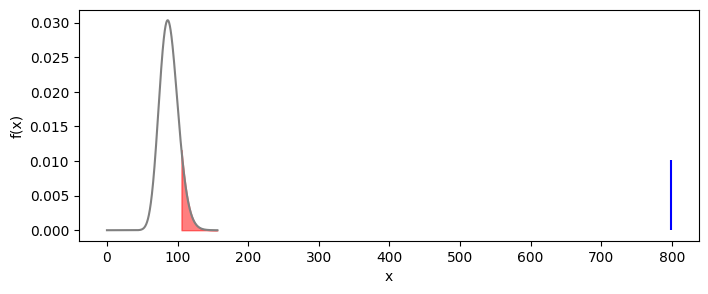

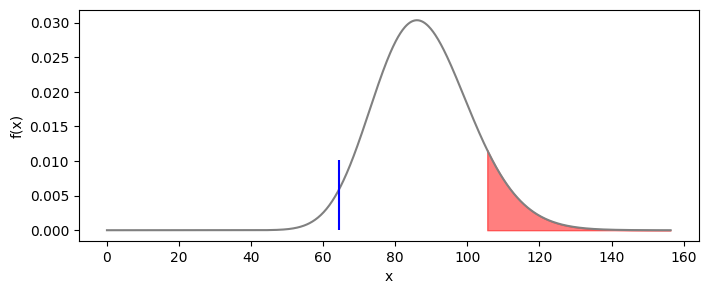

In [21]:
# Komórka testowa
test_result_2 = chi2_uniform_poisson(test_points_1, poland.geometry[0], [10,10], alpha=0.1)
assert np.isclose(test_result_2[0], 798.2435969397935)
assert np.isclose(test_result_2[1], 6.016632536340681e-115)
assert np.isclose(test_result_2[2], 1)

test_result_3 = chi2_uniform_poisson(test_points_2, poland.geometry[0], [10,10], alpha=0.1)
assert np.isclose(test_result_3[0], 64.31008733858239)
assert np.isclose(test_result_3[1], 0.9729182253753463)
assert np.isclose(test_result_3[2], 0)

#### b) Zastosowanie funkcji 

Wykorzystaj funkcję `chi2_uniform_poisson()` przygotowaną w poprzednim podpunkcie do przeprowadzenia testów o następujących parametrach dla wczytanych do notatnika rozkładów (`points_4`, `points_5` i `points_6`):
- siatka pomiarowa: 15x15
- poziom istotności: 0.05

Zapisz wyniki przeprowadzonych testów do zmiennych `chi2_test_points_4`, `chi2_test_points_5` i `chi2_test_points_6`.

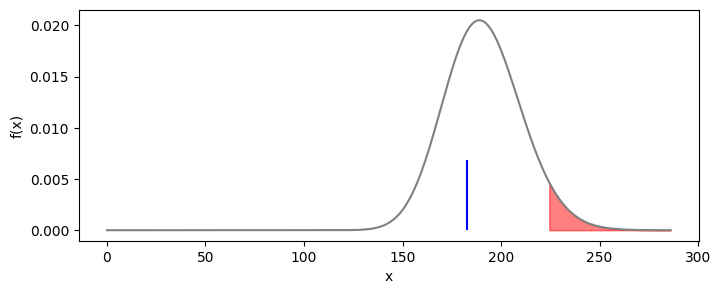

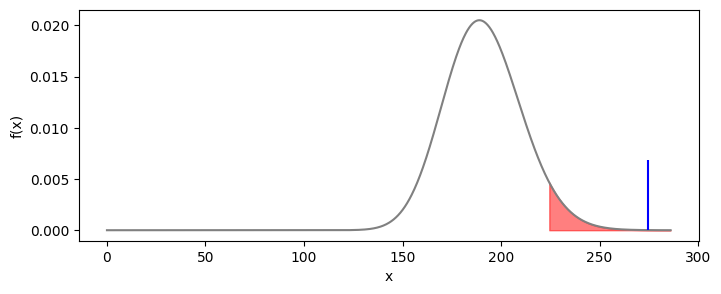

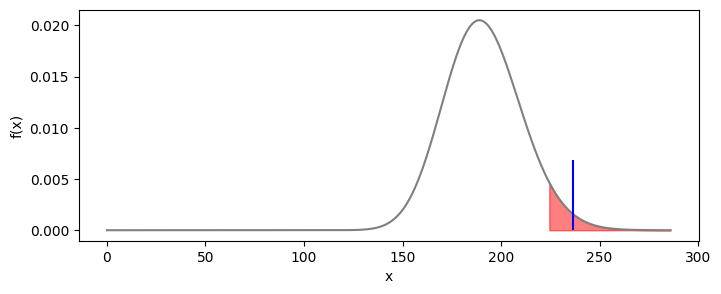

In [22]:
chi2_test_points_4 = chi2_uniform_poisson(points_4, poland.geometry[0], [15, 15], 0.05)
chi2_test_points_5 = chi2_uniform_poisson(points_5, poland.geometry[0], [15, 15], 0.05)
chi2_test_points_6 = chi2_uniform_poisson(points_6, poland.geometry[0], [15, 15], 0.05)

In [23]:
# Komórka testowa
assert np.isclose(chi2_test_points_4[0], 182.53361018265096)
assert np.isclose(chi2_test_points_4[1], 0.6574463136304238)
assert np.isclose(chi2_test_points_4[2], 0)

assert np.isclose(chi2_test_points_5[0], 274.78121185807663)
assert np.isclose(chi2_test_points_5[1], 6.77001317531075e-05)
assert np.isclose(chi2_test_points_5[2], 1)

assert np.isclose(chi2_test_points_6[0], 236.3163040151948)
assert np.isclose(chi2_test_points_6[1], 0.014242828646302648)
assert np.isclose(chi2_test_points_6[2], 1)

### Zadanie 2: Test Kołmogorowa-Smirnowa [8 pkt]

#### a) Przygotowanie funkcji

Przygotuj funkcję `ks_uniform_poisson()` tak, aby przeprowadzała test zgodności brzegowych rozkładów X i Y z jednorodnym procesem Poissona (CSR), a następnie wizualizowała wynik testu z wykorzystaniem funkcji `vizualize_test_result()`.

Algorytm postępowania:

1. Korzystając z własności `geopandas.GeoDataFrame.geometry.x` i `geopandas.GeoDataFrame.geometry.y` wyodrębnij z geometrii rozkładu współrzędne X i Y poszczególnych punktów.

2. Korzystając z funkcji `scipy.stats.kstest()` wykonaj niezależnie testy Kołmogorowa-Smirnowa dla współrzędnej X i Y. Wywołując funkcję ustaw wartość argumentu `method="exact"`.

3. Połącz wyniki testów w sposób konserwatywny:
   - statystyka zbiorcza: $ D = \max(D_x, D_y)$,
   - Wartość p-value: $ p = \min(p_x, p_y)$.

4. Podejmij decyzję weryfikującą i zapisz wynik jako zmienną `H` (1 — odrzucenie H0, 0 — brak podstaw do odrzucenia H0).

5. Przygotuj wizualizację wyniku testu:
   - Korzystając z `scipy.stats.kstwo.ppf()` z odpowiednio dobraną liczebnością próbki oblicz wartość krytyczną rozkładu Kołmogorowa-Smirnowa dla przeprowadzonego testu.  
   - Korzystając z funkcji `numpy.linspace()` lub `numpy.arange()` oraz `scipy.stats.kstwo.pdf()` z odpowiednio dobraną liczebnością próbki zbuduj tabelę wartości funkcji gęstości rozkładu chi-kwadrat (kolumny `x` - wartości zmiennej i `pdf` - gęstość prawdopodobieństwa) w zakresie od 0 do wysokiego percentyla (np. 0.99999) obliczonej z wykorzystaniem funkcji `scipy.stats.kstwo.ppf()`.  
   - Wykorzystaj funkcję `vizualize_test_result()` do zwizualiwoania wyniku testu.

6. Zwróć wartości `D`, `pvalue` i `H`.

In [24]:
def ks_uniform_poisson(points, cdf_x, cdf_y, alpha):
    """
    Parameters
    ----------
    points : geopandas.GeoDataFrame
        Zbiór punktów wejściowych - proces punktowy poddawany testowi.
    cdf_x, cdf_y : callable
        Funkcje dystrybuant kompatybilne z scipy.stats.kstest().
    alpha : float
        Poziom istotności testu.
    plot : bool
        Czy wyświetlić wykresy diagnostyczne? Domyślnie False.

    Returns
    -------
    D : float
        Statystyka testowa: max(ks_x, ks_y).
    pvalue : float
        Wspólne p-value: min(p_x, p_y).
    H : int
        1 jeśli odrzucamy H0 na poziomie alpha, w przeciwnym razie 0.
    """
    
    x = points.geometry.x
    y = points.geometry.y

    stat_x, pvalue_x = sp.stats.kstest(x, cdf_x,  method="exact")
    stat_y, pvalue_y = sp.stats.kstest(y, cdf_y, method="exact")

    D = max(stat_x, stat_y)
    p = min(pvalue_x, pvalue_y)

    H = int(p <= alpha)

    wart_kryt = sp.stats.kstwo.ppf(1 - alpha, len(points))

    x_max = sp.stats.kstwo.ppf(0.99999, len(points))
    x = np.linspace(0, x_max, 1000)
    pdf = sp.stats.kstwo.pdf(x, len(points))

    pdf_df = pd.DataFrame(
        pdf,
        index=x,
        columns=["f(D)"]
    )

    vizualize_test_result(
        pdf_df,
        D,
        [wart_kryt, np.inf, "inner"]
    )

    
    return D, p, H

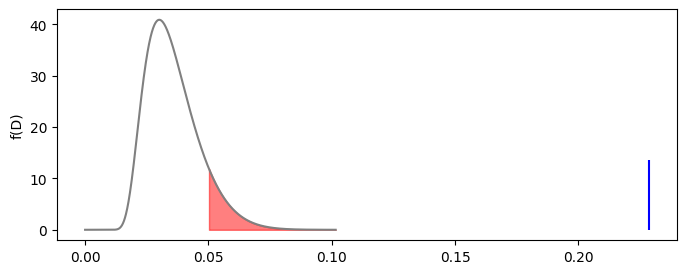

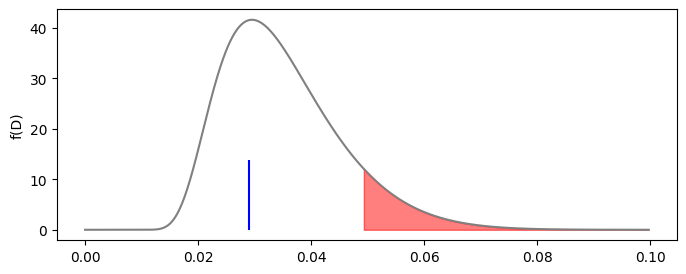

In [25]:
# Komórka testowa
test_result_4 = ks_uniform_poisson(test_points_1, cdf_x, cdf_y, alpha=0.1)
assert np.isclose(test_result_4[0], 0.22848076040234916)
assert np.isclose(test_result_4[1], 2.0414960736655487e-27)
assert np.isclose(test_result_4[2], 1)

test_result_5 = ks_uniform_poisson(test_points_2, cdf_x, cdf_y, alpha=0.1)
assert np.isclose(test_result_5[0], 0.02897098638844231)
assert np.isclose(test_result_5[1], 0.6750948324921389)
assert np.isclose(test_result_5[2], 0)

#### b) Zastosowanie funkcji 

Wykorzystaj funkcję `ks_uniform_poisson()` przygotowaną w poprzednim podpunkcie do przeprowadzenia testów o następujących parametrach dla wczytanych do notatnika rozkładów (`points_4`, `points_5` i `points_6`):
- poziom istotności: 0.05
- dystrybuanty rozkładu jednorodnego na poligonie: funkcje zawarte w zmiennych `cdf_x` i `cdf_y`

Zapisz wyniki przeprowadzonych testów do zmiennych `ks_test_points_4`, `ks_test_points_5` i `kstest_points_6`.

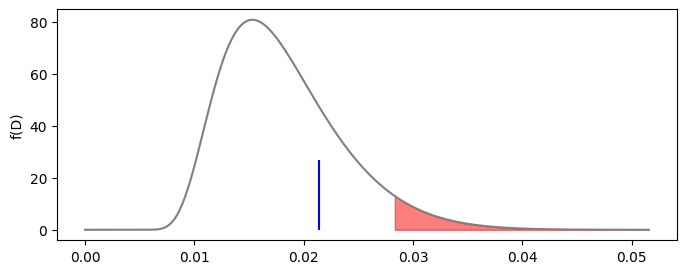

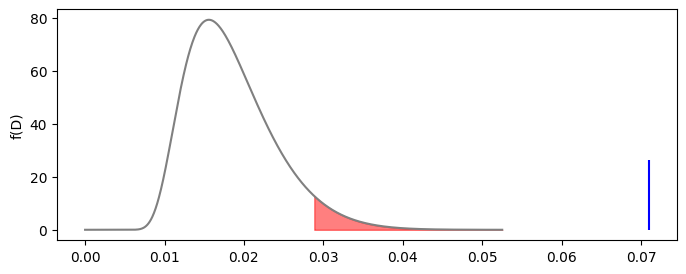

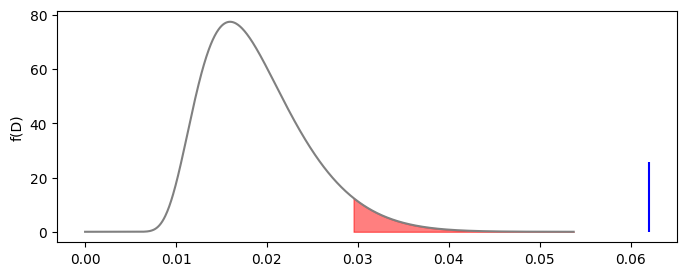

In [26]:
ks_test_points_4 = ks_uniform_poisson(points_4, cdf_x, cdf_y, 0.05)
ks_test_points_5 = ks_uniform_poisson(points_5, cdf_x, cdf_y, 0.05)
ks_test_points_6 = ks_uniform_poisson(points_6, cdf_x, cdf_y, 0.05)

In [27]:
# Komórka testowa
assert np.isclose(ks_test_points_4[0], 0.02142646781801638)
assert np.isclose(ks_test_points_4[1], 0.24059829134317223)
assert np.isclose(ks_test_points_4[2], 0)

assert np.isclose(ks_test_points_5[0], 0.07097097097757121)
assert np.isclose(ks_test_points_5[1], 4.205068554766077e-10)
assert np.isclose(ks_test_points_5[2], 1)

assert np.isclose(ks_test_points_6[0], 0.061994242820596845)
assert np.isclose(ks_test_points_6[1], 1.7679161607115905e-07)
assert np.isclose(ks_test_points_6[2], 1)